In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn.datasets
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
RANDOM_STATE = 2

In [30]:
# Loading data from sklearn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [31]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [32]:
# Loading the data to a data frame
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [33]:
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [34]:
# Adding the 'target' column to the data frame
data_frame['label'] = breast_cancer_dataset.target

In [35]:
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [36]:
# total number of rows adn columns in the dataset
data_frame.shape

(569, 31)

In [37]:
print("Shape:", data_frame.shape)
print("\nMissing values per column:")
print(data_frame.isnull().sum().sum(), "total missing values")
data_frame.info()

Shape: (569, 31)

Missing values per column:
0 total missing values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error  

In [38]:
# Checking for missing values
data_frame.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

In [39]:
# Statistical measures about the data
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**Label meaning** - `0` = Malignant, `1` = Benign (this is the opposite of what intuition might
suggest, so it's worth keeping explicit everywhere in this notebook to avoid mix-ups downstream).

In [40]:
print(data_frame['label'].value_counts())
data_frame.groupby('label').mean(numeric_only=True)

label
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


Seperating the features and targets - 

In [41]:
X = data_frame.drop(columns='label', axis = 1)
Y = data_frame['label']

In [42]:
print(X)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [43]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: label, Length: 569, dtype: int64


### Exploratory Visualization :-

C:\Users\hk821\AppData\Local\Temp\ipykernel_24408\2699284907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=["#e57373", "#64b5f6"])


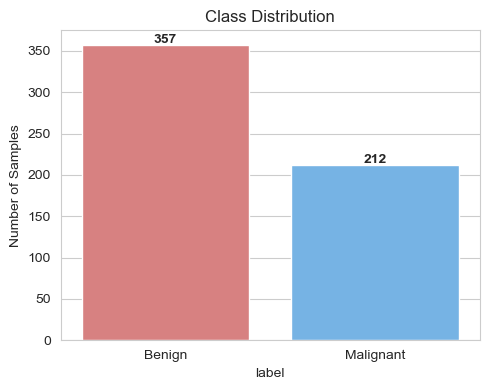

Class balance: 0.59 (minority/majority ratio)


In [44]:
label_names = {0: "Malignant", 1: "Benign"}
counts = data_frame['label'].map(label_names).value_counts()

plt.figure(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, palette=["#e57373", "#64b5f6"])
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("Class balance:", round(counts.min() / counts.max(), 2), "(minority/majority ratio)")

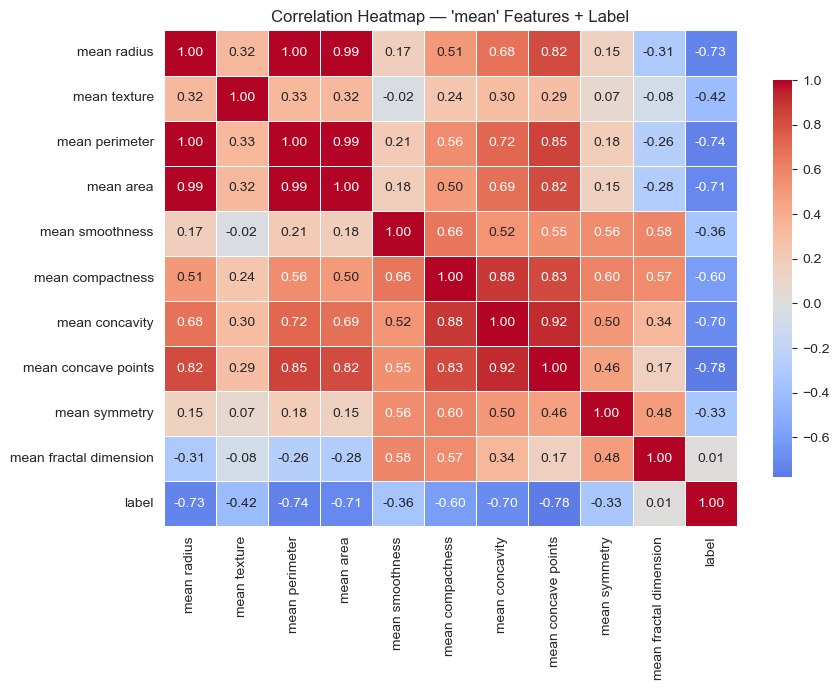

In [45]:
mean_features = [c for c in data_frame.columns if c.startswith('mean')]
corr_mean = data_frame[mean_features + ['label']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_mean, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — 'mean' Features + Label")
plt.tight_layout()
plt.show()

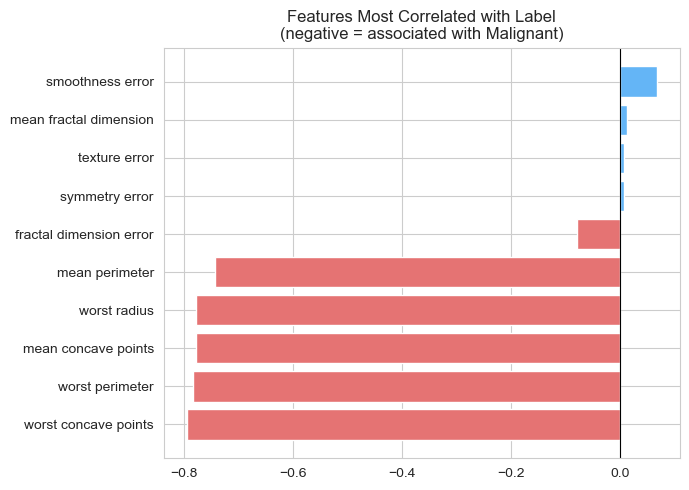

In [46]:
# Which individual features correlate most strongly with the label?
label_corr = data_frame.corr(numeric_only=True)['label'].drop('label').sort_values()
top_corr = pd.concat([label_corr.head(5), label_corr.tail(5)])

plt.figure(figsize=(7, 5))
colors = ['#e57373' if v < 0 else '#64b5f6' for v in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Features Most Correlated with Label\n(negative = associated with Malignant)")
plt.tight_layout()
plt.show()

C:\Users\hk821\AppData\Local\Temp\ipykernel_24408\1314370441.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_frame, x=data_frame['label'].map(label_names), y=feature, ax=ax,
C:\Users\hk821\AppData\Local\Temp\ipykernel_24408\1314370441.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_frame, x=data_frame['label'].map(label_names), y=feature, ax=ax,
C:\Users\hk821\AppData\Local\Temp\ipykernel_24408\1314370441.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_frame, x=data_frame['label'].map(label_names), y

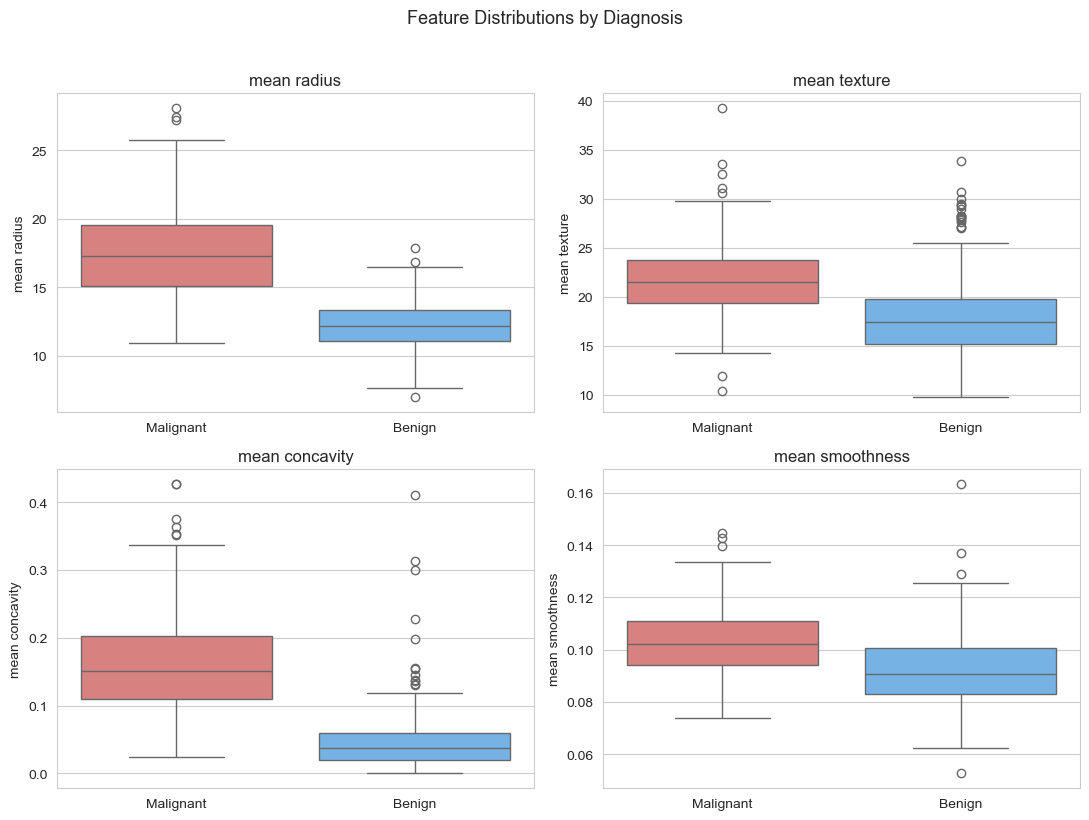

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features_to_plot = ['mean radius', 'mean texture', 'mean concavity', 'mean smoothness']

for ax, feature in zip(axes.flat, features_to_plot):
    sns.boxplot(data=data_frame, x=data_frame['label'].map(label_names), y=feature, ax=ax,
                palette=["#e57373", "#64b5f6"])
    ax.set_xlabel("")
    ax.set_title(feature)

plt.suptitle("Feature Distributions by Diagnosis", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### Train Test Split :-
- Using `stratify=Y` so the malignant/benign ratio is preserved identically in both the train and
test sets - important given the ~37/63 class split.

##### Splitting the data into training data and test data

In [48]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [49]:
print(X.shape, X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


### Model Training :-
#### Logistic Regression - 

In [50]:
model = LogisticRegression(max_iter=5000)

In [51]:
model

LogisticRegression(max_iter=5000)

In [52]:
model.fit(X_train, Y_train)

LogisticRegression(max_iter=5000)

#### Accuracy on training data

In [53]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [54]:
print("Training on Accuracy Data :", training_data_accuracy)

Training on Accuracy Data : 0.9692307692307692


#### Accuracy on test data

In [55]:
X_test_prediction = model.predict(X_test)
test_data_prediction = accuracy_score(Y_test, X_test_prediction)

In [56]:
print("Test data of Accuracy :", test_data_prediction)

Test data of Accuracy : 0.9298245614035088


In [57]:
X = data_frame.drop(columns='label')
Y = data_frame['label']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE, stratify=Y
)

print("Full set:", X.shape)
print("Train set:", X_train.shape, "| class balance:", Y_train.value_counts(normalize=True).round(2).to_dict())
print("Test set: ", X_test.shape, "| class balance:", Y_test.value_counts(normalize=True).round(2).to_dict())

Full set: (569, 30)
Train set: (455, 30) | class balance: {1: 0.63, 0: 0.37}
Test set:  (114, 30) | class balance: {1: 0.63, 0: 0.37}


### Model Comparison (5-Fold Stratified Cross-Validation)

Each candidate model is wrapped in a `Pipeline` with `StandardScaler` so that scaling is fit
*inside* each CV fold (avoiding leakage from the validation fold into training). We compare on
accuracy, precision, recall, F1, and ROC-AUC - not accuracy alone - since missing a malignant
case (a false negative) is far more costly than a false positive in this setting.

In [58]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, clf in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", clf)
    ])
    cv_results = cross_validate(pipe, X_train, Y_train, cv=cv, scoring=scoring)
    row = {"Model": name}
    for s in scoring:
        row[s] = cv_results[f"test_{s}"].mean()
        row[s + "_std"] = cv_results[f"test_{s}"].std()
    results.append(row)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df[["Model", "accuracy", "precision", "recall", "f1", "roc_auc"]].round(4)

,Model,accuracy,precision,recall,f1,roc_auc
0,SVM (RBF),0.9692,0.9758,0.9754,0.9753,0.9957
1,Gradient Boosting,0.9538,0.9563,0.9719,0.9636,0.9913
2,Logistic Regression,0.9692,0.9697,0.9825,0.9758,0.9906
3,Random Forest,0.9538,0.9560,0.9719,0.9637,0.9899


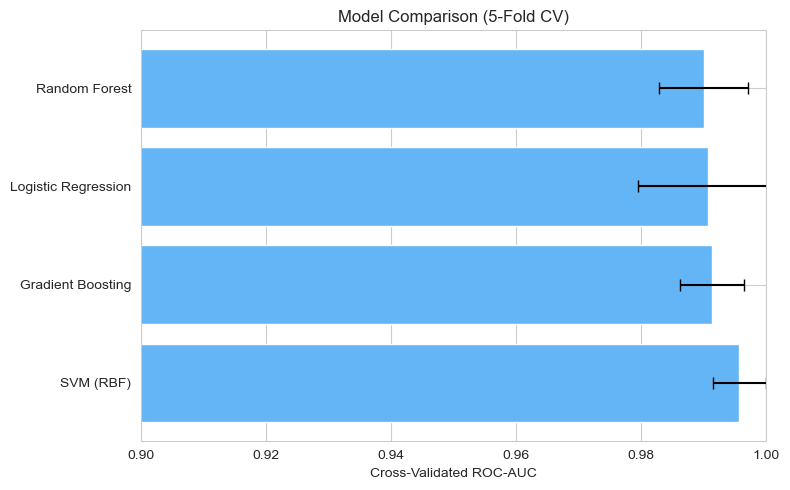

Best model by CV ROC-AUC: SVM (RBF)


In [59]:
plt.figure(figsize=(8, 5))
plt.barh(results_df["Model"], results_df["roc_auc"], xerr=results_df["roc_auc_std"],
         color="#64b5f6", capsize=4)
plt.xlabel("Cross-Validated ROC-AUC")
plt.title("Model Comparison (5-Fold CV)")
plt.xlim(0.9, 1.0)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"Best model by CV ROC-AUC: {best_model_name}")

### Fit the final model

In [60]:
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", models[best_model_name])
])

final_pipeline.fit(X_train, Y_train)

train_pred = final_pipeline.predict(X_train)
test_pred = final_pipeline.predict(X_test)
test_proba = final_pipeline.predict_proba(X_test)[:, 1]  # probability of class 1 (Benign)

print(f"Final model: {best_model_name}")
print("Training accuracy:", round(accuracy_score(Y_train, train_pred), 4))
print("Test accuracy:    ", round(accuracy_score(Y_test, test_pred), 4))
print("Test ROC-AUC:     ", round(roc_auc_score(Y_test, test_proba), 4))

Final model: SVM (RBF)
Training accuracy: 0.9802
Test accuracy:     0.9825
Test ROC-AUC:      0.997


### Evaluation

In [61]:
print(classification_report(Y_test, test_pred, target_names=["Malignant (0)", "Benign (1)"]))

               precision    recall  f1-score   support

Malignant (0)       1.00      0.95      0.98        42
   Benign (1)       0.97      1.00      0.99        72

     accuracy                           0.98       114
    macro avg       0.99      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



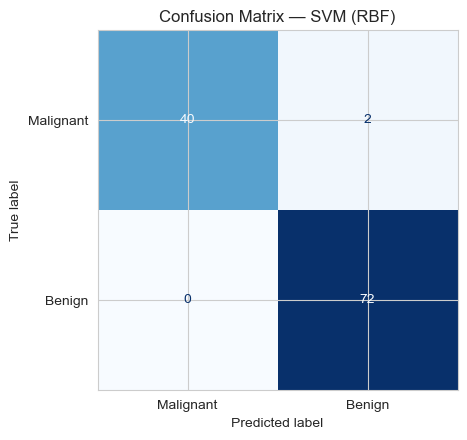

False negatives (missed malignant cases): 0
False positives (benign flagged as malignant): 2


In [62]:
cm = confusion_matrix(Y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"False negatives (missed malignant cases): {fn}")
print(f"False positives (benign flagged as malignant): {fp}")

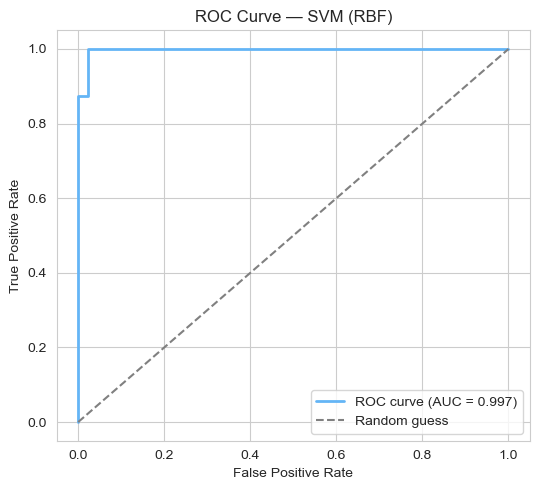

In [63]:
fpr, tpr, thresholds = roc_curve(Y_test, test_proba)
auc = roc_auc_score(Y_test, test_proba)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, color="#64b5f6", linewidth=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretability

Permutation importance is used here instead of raw coefficients or `feature_importances_` because
it's model-agnostic - it works the same way regardless of which model (SVM, tree-based, or linear)
ends up winning the comparison above. It measures how much the ROC-AUC drops when a feature's
values are randomly shuffled.

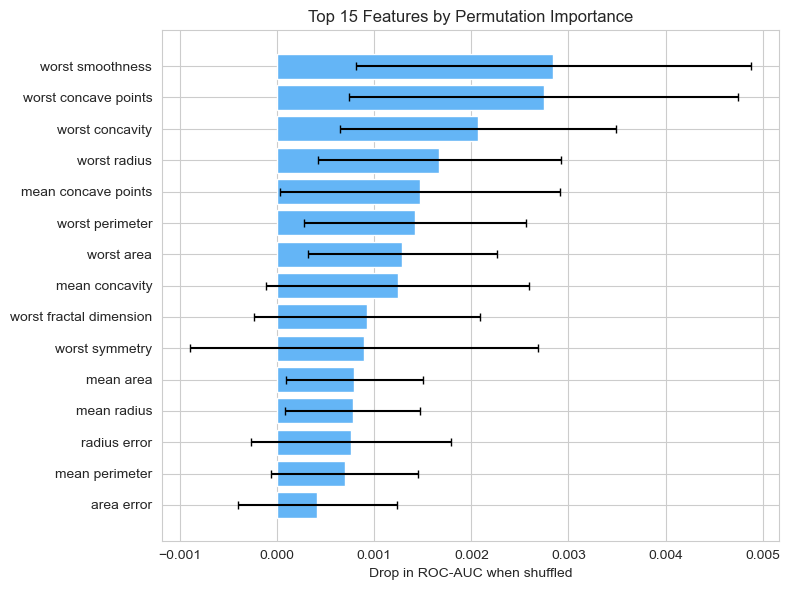

In [64]:
perm = permutation_importance(
    final_pipeline, X_test, Y_test, n_repeats=20, random_state=RANDOM_STATE, scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
         xerr=importance_df["std"][::-1], color="#64b5f6", capsize=3)
plt.xlabel("Drop in ROC-AUC when shuffled")
plt.title("Top 15 Features by Permutation Importance")
plt.tight_layout()
plt.show()

### Predictive System

A single function wraps prediction so the label logic only needs to be correct in one place.
**`0` = Malignant, `1` = Benign** - matching the dataset's original encoding throughout.

In [65]:
def predict_tumor(input_data, pipeline=final_pipeline, feature_names=X.columns):
    """
    input_data: tuple/list/array of 30 feature values in the same order as the dataset's
                feature_names.
    Returns: (label_int, label_text, probability_of_malignant)
    """
    input_df = pd.DataFrame([input_data], columns=feature_names)
    pred = pipeline.predict(input_df)[0]
    proba = pipeline.predict_proba(input_df)[0]

    label_text = "Malignant" if pred == 0 else "Benign"
    prob_malignant = proba[0]  # class 0 = Malignant

    return pred, label_text, prob_malignant


# Example: a real sample from the dataset, with its true label, to sanity-check the function
sample_idx = 0
true_label = "Malignant" if Y.iloc[sample_idx] == 0 else "Benign"
sample_values = tuple(X.iloc[sample_idx].values)

pred, label_text, prob_malignant = predict_tumor(sample_values)

print(f"True label:      {true_label}")
print(f"Predicted label: {label_text}")
print(f"P(Malignant):    {prob_malignant:.4f}")

True label:      Malignant
Predicted label: Malignant
P(Malignant):    0.9785


### Save the trained model

In [66]:
joblib.dump(final_pipeline, "breast_cancer_model.pkl")
print("Saved final_pipeline (scaler + model) to breast_cancer_model.pkl")
print("Reload with: joblib.load('breast_cancer_model.pkl')")

Saved final_pipeline (scaler + model) to breast_cancer_model.pkl
Reload with: joblib.load('breast_cancer_model.pkl')


#### Building a Predictive System

In [67]:
input_data = (13.08,15.71,85.63,520,0.1075,0.127,0.04568,0.0311,0.1967,0.06811,
              0.1852,0.7477,1.383,14.67,0.004097,0.01898,0.01698,0.00649,0.01678,
              0.002425,14.5,20.49,96.09,630.5,0.1312,0.2776,0.189,0.07283,0.3184,0.08183)

input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = final_pipeline.predict(input_data_reshaped) 
print(prediction)

if prediction[0] == 0:
    print("The Breast Cancer is Malignant")
else:
    print("The Breast Cancer is Benign")

[1]
The Breast Cancer is Benign


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Summary

- Compared four models (Logistic Regression, Random Forest, SVM, Gradient Boosting) using 5-fold
  stratified cross-validation on accuracy, precision, recall, F1, and ROC-AUC.
- Selected the best model by cross-validated ROC-AUC, fit it inside a `Pipeline` with
  `StandardScaler` to prevent data leakage.
- Evaluated on a held-out test set with a confusion matrix, classification report, and ROC curve,
  with explicit attention to false negatives (missed malignant cases).
- Added model-agnostic permutation importance for interpretability.
- Fixed the original notebook's inverted label logic (`0` = Malignant, `1` = Benign) and wrapped
  prediction in a single reusable function to prevent that class of bug from recurring.
- Saved the fitted pipeline with `joblib` so it can be reloaded directly (e.g. in a Flask
  endpoint) without retraining.